In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


In [5]:
np.random.seed(42)
data = pd.read_csv('50_Startups.csv')
data

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [7]:
print('Missing Values:\n', data.isnull().sum())
print('\nDuplicates:', data.duplicated().sum())

Missing Values:
 R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Duplicates: 0


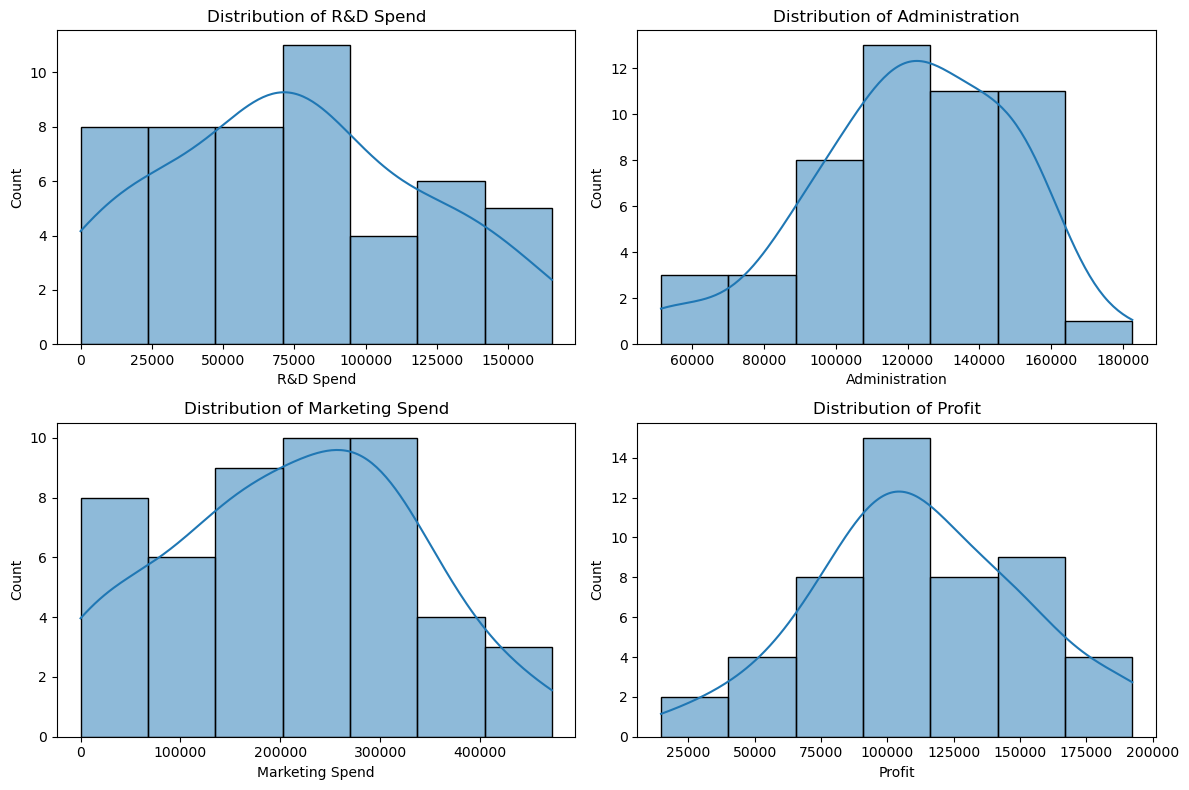

In [8]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit'],1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

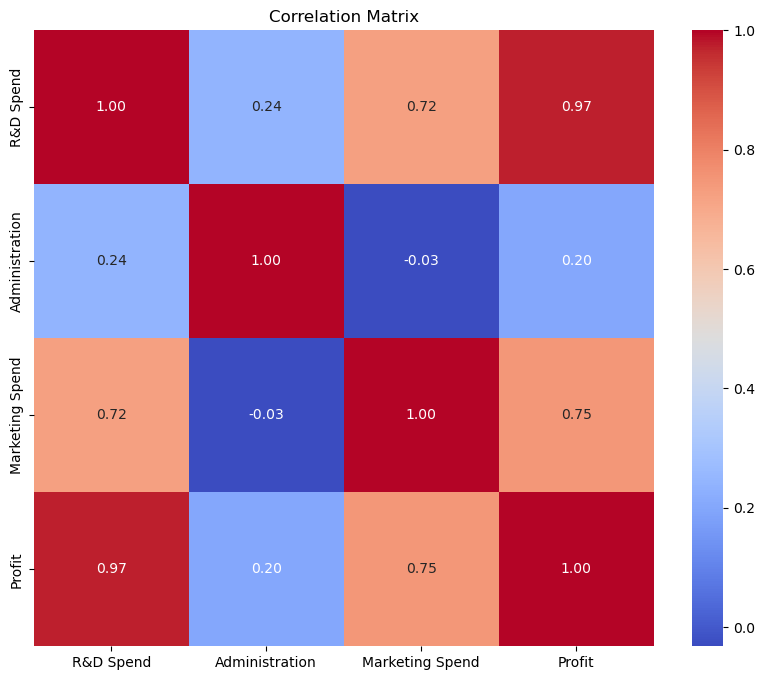

In [9]:
plt.figure(figsize=(10, 8))
corr_matrix = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title('Correlation Matrix')
plt.show()

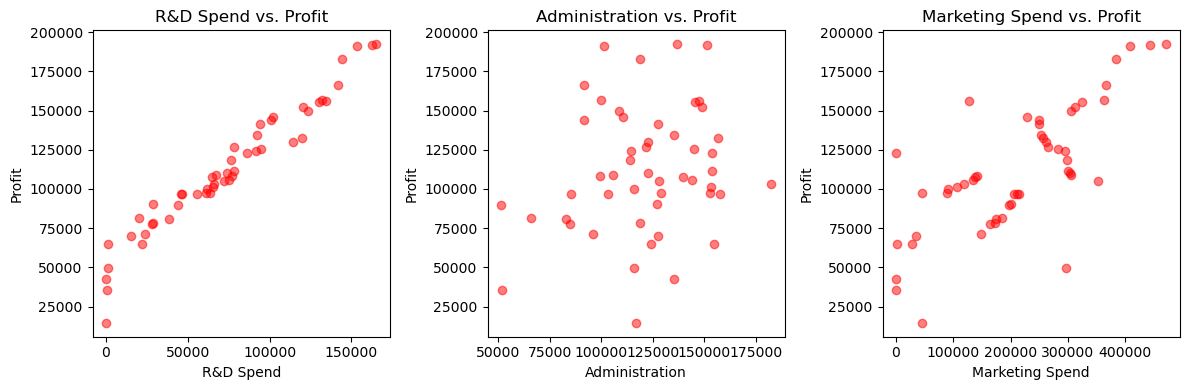

In [12]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(['R&D Spend', 'Administration', 'Marketing Spend'], 1):
    plt.subplot(1, 3, i)
    plt.scatter(data[col], data['Profit'],color='red' ,alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('Profit')
    plt.title(f'{col} vs. Profit')
plt.tight_layout()
plt.show()


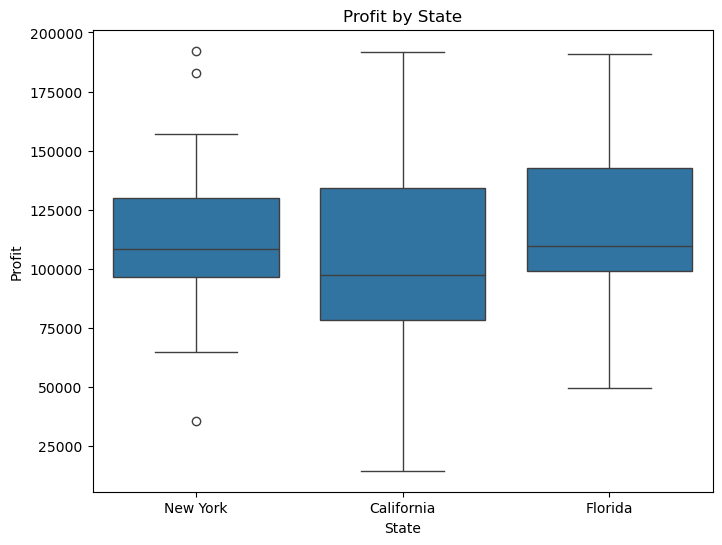

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='State', y='Profit', data=data)
plt.title('Profit by State')
plt.show()

In [14]:
X = data.drop('Profit', axis=1)
y = data['Profit']
X.head(10)

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


In [15]:
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [16]:
num_cols = ['R&D Spend', 'Administration', 'Marketing Spend']
cat_cols = ['State']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols)
    ])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [ ]:

feature_names = num_cols + [f"State_{state}" for state in preprocessor.named_transformers_['cat'].categories_[0][:]]


In [21]:
X_train_rd = X_train[['R&D Spend']]
X_test_rd = X_test[['R&D Spend']]
scaler_rd = StandardScaler()
X_train_rd_scaled = scaler_rd.fit_transform(X_train_rd)
X_test_rd_scaled = scaler_rd.transform(X_test_rd)

In [ ]:
X_train_rd_scaled